# <center>Vision Transformer(s)<center>

## ***Introducere***

***Am folosit***
[Vision Transformer (ViT)](https://arxiv.org/abs/2010.11929)

***Detectam un avion intr-o imagine data folosind acest dataset:***
[Caltech 101 dataset](https://data.caltech.edu/records/mzrjq-6wc02)

***Avem nevoie de tf 2.4 si aceste addon-uri***
[TensorFlow Addons](https://www.tensorflow.org/addons/overview),
***din care importăm `AdamW`.***

***TensorFlow Addons poate fi instalat:***

***pip install -U tensorflow-addons***

## <center>Imports & setup<center>

In [1]:
pip install -U tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 11.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: tensorflow-addons
    Found existing installation: tensorflow-addons 0.20.0
    Uninstalling tensorflow-addons-0.20.0:
      Successfully uninstalled tensorflow-addons-0.20.0
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import scipy.io
import shutil

# <center>Preparam dataset-ul<center>

Folosim [Caltech 101 Dataset](http://www.vision.caltech.edu/Image_Datasets/Caltech101/).

In [3]:
path_images = "/101_ObjectCategories/airplanes/"
path_annot = "/Annotations/Airplanes_Side_2/"

path_to_downloaded_file = keras.utils.get_file(
    fname = "caltech_101_zipped",
    origin = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip",
    extract = True,
    archive_format = "zip",
    cache_dir = "/", 
)

# Extract la tar-urile din zip
shutil.unpack_archive("/datasets/caltech-101/101_ObjectCategories.tar.gz", "/")
shutil.unpack_archive("/datasets/caltech-101/Annotations.tar", "/")

image_paths = [
    f for f in os.listdir(path_images) if os.path.isfile(os.path.join(path_images, f))
]
annot_paths = [
    f for f in os.listdir(path_annot) if os.path.isfile(os.path.join(path_annot, f))
]

image_paths.sort()
annot_paths.sort()

image_size = 224  # rescale

images, targets = [], []

# stocam imaginile si adnotarile
for i in range(0, len(annot_paths)):
    # bounding box-ul
    annot = scipy.io.loadmat(path_annot + annot_paths[i])["box_coord"][0]

    top_left_x, top_left_y = annot[2], annot[0]
    bottom_right_x, bottom_right_y = annot[3], annot[1]

    image = keras.utils.load_img(
        path_images + image_paths[i],
    )
    (w, h) = image.size[:2]

    # Rescaling
    if i < int(len(annot_paths) * 0.8):
        image = image.resize((image_size, image_size))

    # lucram cu bytecodes
    images.append(keras.utils.img_to_array(image))

    # pt ca am dat rescale la poza dam si la bounding box
    targets.append(
        (
            float(top_left_x) / w,
            float(top_left_y) / h,
            float(bottom_right_x) / w,
            float(bottom_right_y) / h,
        )
    )

# Trecem la np array si facem train-test split 80-20
(x_train), (y_train) = (
    np.asarray(images[: int(len(images) * 0.8)]),
    np.asarray(targets[: int(len(targets) * 0.8)]),
)
(x_test), (y_test) = (
    np.asarray(images[int(len(images) * 0.8) :]),
    np.asarray(targets[int(len(targets) * 0.8) :]),
)

137414764/137414764 [==============================] - 7s 0us/step


/tmp/ipykernel_32/2708003110.py:66: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.asarray(images[int(len(images) * 0.8) :]),


# <center>Implementarea de multilayer-perceptron (MLP)<center>

MLP = 1 input layer, 1 sau mai multe hidden layere, 1 output layer, iar toate sunt fully connected cu weights

In [4]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation = tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# <center>Patch creation layer<center>

In [5]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    # Override
    def get_config(self):
        config = super().get_config().copy()
        config.update(
            {
                "input_shape": input_shape,
                "patch_size": patch_size,
                "num_patches": num_patches,
                "projection_dim": projection_dim,
                "num_heads": num_heads,
                "transformer_units": transformer_units,
                "transformer_layers": transformer_layers,
                "mlp_head_units": mlp_head_units,
            }
        )
        return config

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images = images,
            sizes = [1, self.patch_size, self.patch_size, 1],
            strides = [1, self.patch_size, self.patch_size, 1],
            rates = [1, 1, 1, 1],
            padding = "VALID",
        )
        # return patches
        return tf.reshape(patches, [batch_size, -1, patches.shape[-1]])


# <center>Un exemplu de impartire in patch-uri<center>

Image size: 224 X 224
Patch size: 32 X 32
49 patches/image 
3072 elements/patch


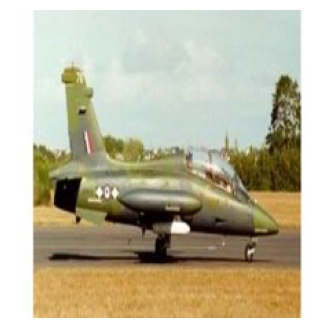

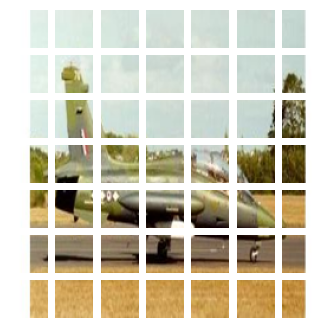

In [6]:
patch_size = 32

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0].astype("uint8"))
plt.axis("off")

patches = Patches(patch_size)(tf.convert_to_tensor([x_train[0]]))
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"{patches.shape[1]} patches/image \n{patches.shape[-1]} elements/patch")


n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")

# <center> Patch encoding Layer <center>

`PatchEncoder` ia fiecare patch si il transforma intr-un vector de dimensiune `projection_dim`. In plus, adauga informatia despre pozitia fiecarui patch in imagine, sub forma unor valori care sunt invatate in timpul antrenarii. Aceste valori se numesc positional embeddings si ajuta modelul sa stie unde se afla fiecare patch in imagine.


In [7]:

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    # Override 
    def get_config(self):
        config = super().get_config().copy()
        config.update(
            {
                "input_shape": input_shape,
                "patch_size": patch_size,
                "num_patches": num_patches,
                "projection_dim": projection_dim,
                "num_heads": num_heads,
                "transformer_units": transformer_units,
                "transformer_layers": transformer_layers,
                "mlp_head_units": mlp_head_units,
            }
        )
        return config

    def call(self, patch):
        positions = tf.range(start = 0, limit = self.num_patches, delta = 1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded


# <center> Modelul VIT <center>

Acest model are mai multe layere de tip Transformer.
`MultiHeadAttention` e folosit pentru mecanismul de self-attention
aplicat pe secventa de patch-uri. Apoi output-ul din patch-urile encodate (skip connection)
si layer-ul self-attention e normalizat si trimis catre MLP.
Ca output primim bounding box-ul obiectului respectiv.

In [8]:
def create_vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
):
    inputs = layers.Input(shape = input_shape)
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        # Prima normalizare de layer
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Nulti-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads = num_heads, key_dim = projection_dim, dropout = 0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # A doua normalizare
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Tensor de forma [batch_size, projection_dim].
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)
    # MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.3)

    bounding_box = layers.Dense(4)(
        features
    )  # Ultimul layer cu cei 4 neuroni care vor da bounding box-ul

    return keras.Model(inputs = inputs, outputs = bounding_box)


# <center>Rulare<center>
***Folosim weight decay, MSE, best-save si early stopping***

In [9]:
def run_experiment(model, learning_rate, weight_decay, batch_size, num_epochs):

    optimizer = tfa.optimizers.AdamW(
        learning_rate = learning_rate, weight_decay = weight_decay
    )

    # Setarile modelului
    model.compile(optimizer = optimizer, loss = keras.losses.MeanSquaredError())

    checkpoint_filepath = "logs/"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor = "val_loss",
        save_best_only = True,
        save_weights_only = True,
    )

    # Train-val split 90-10 (este train-ul de dupa train-test split)
    history = model.fit(
        x = x_train,
        y = y_train,
        batch_size = batch_size,
        epochs = num_epochs,
        validation_split = 0.1,
        callbacks = [
            checkpoint_callback,
            keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10),
        ],
    )

    return history


input_shape = (image_size, image_size, 3)  
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 32
num_epochs = 100
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
# Size of the transformer layers
transformer_units = [
    projection_dim * 2,
    projection_dim,
]
transformer_layers = 4
mlp_head_units = [2048, 1024, 512, 64, 32] 


history = []
num_patches = (image_size // patch_size) ** 2

vit_object_detector = create_vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
)

history = run_experiment(
    vit_object_detector, learning_rate, weight_decay, batch_size, num_epochs
)


Epoch 1/100
18/18 [==============================] - 8s 99ms/step - loss: 0.7291 - val_loss: 0.2206
Epoch 2/100
18/18 [==============================] - 1s 60ms/step - loss: 0.2709 - val_loss: 0.1893
Epoch 3/100
18/18 [==============================] - 1s 50ms/step - loss: 0.1878 - val_loss: 0.0755
Epoch 4/100
18/18 [==============================] - 1s 51ms/step - loss: 0.1016 - val_loss: 0.0180
Epoch 5/100
18/18 [==============================] - 1s 58ms/step - loss: 0.0640 - val_loss: 0.0055
Epoch 6/100
18/18 [==============================] - 1s 58ms/step - loss: 0.0460 - val_loss: 0.0042
Epoch 7/100
18/18 [==============================] - 1s 60ms/step - loss: 0.0352 - val_loss: 0.0032
Epoch 8/100
18/18 [==============================] - 0s 24ms/step - loss: 0.0303 - val_loss: 0.0041
Epoch 9/100
18/18 [==============================] - 1s 59ms/step - loss: 0.0277 - val_loss: 0.0018
Epoch 10/100
18/18 [==============================] - 0s 24ms/step - loss: 0.0240 - val_loss: 0.0022

# <center> Testare si afisare rezultate<center>

1/1 [==============================] - 0s 22ms/step
Mean IoU: 1.3576554396555445


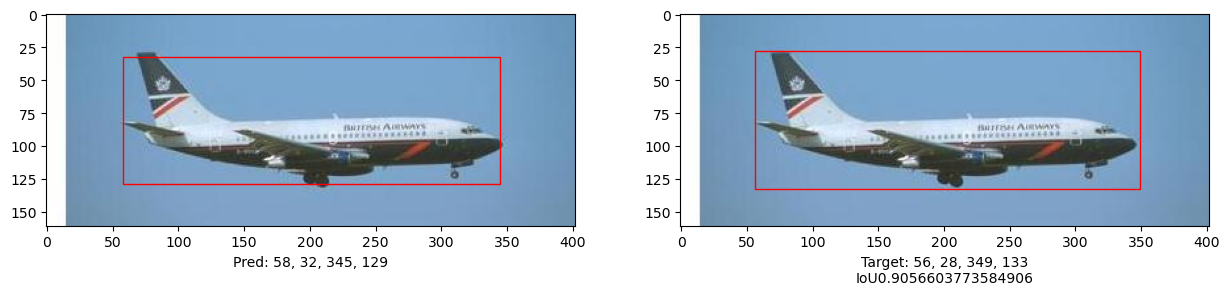

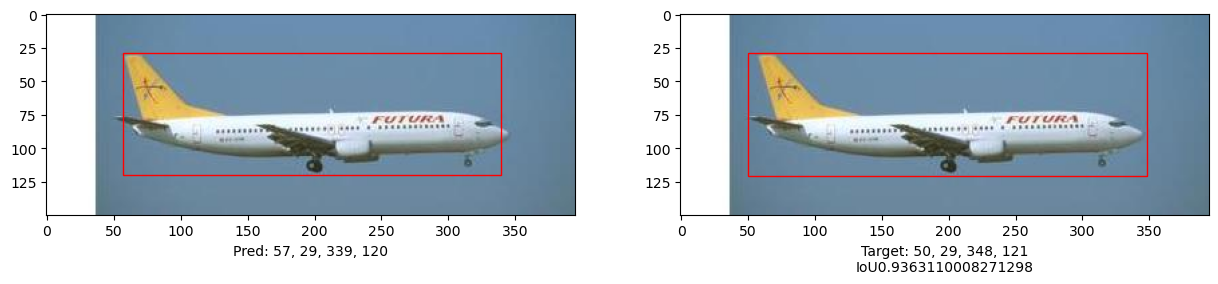

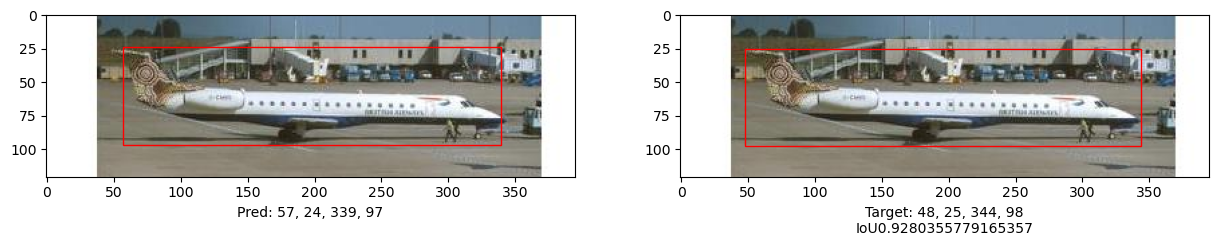

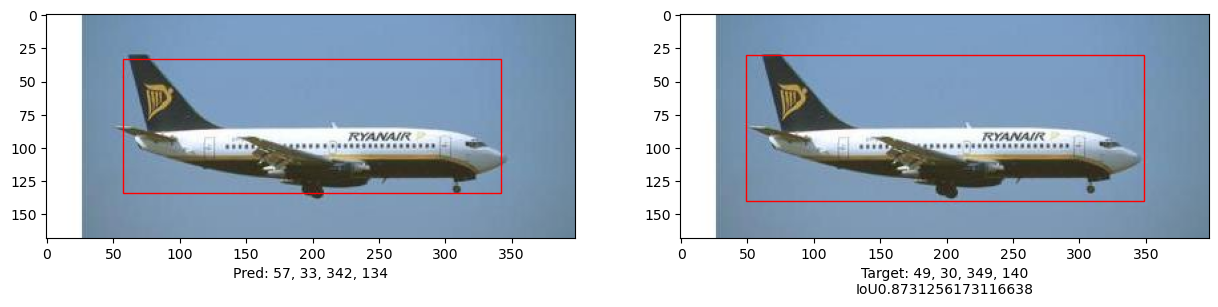

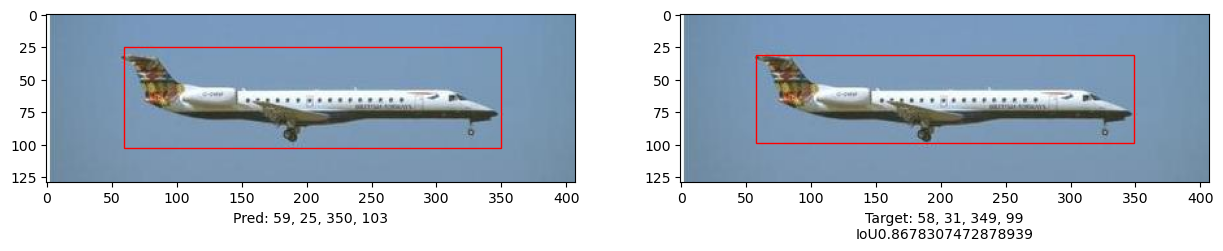

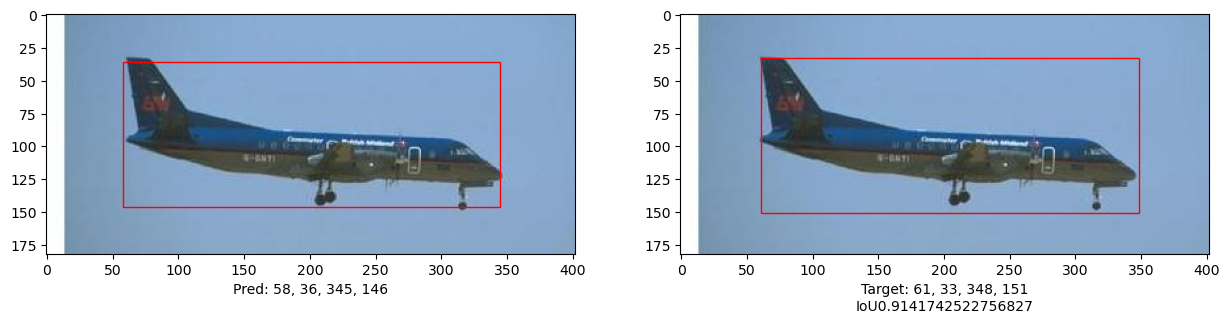

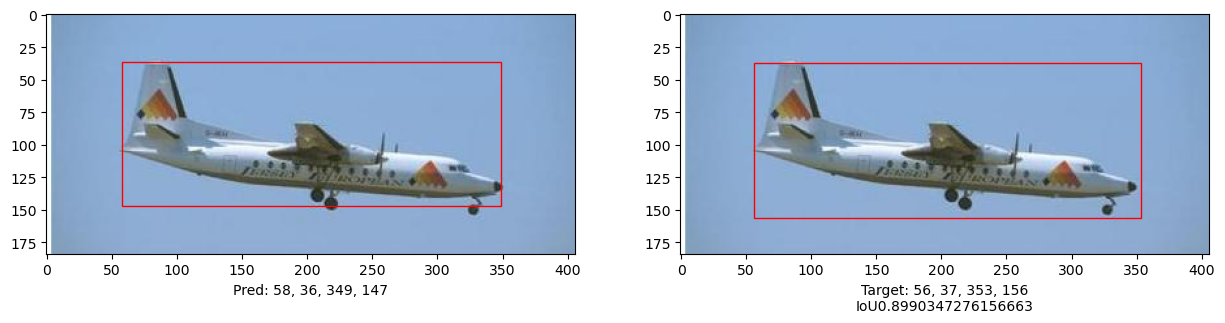

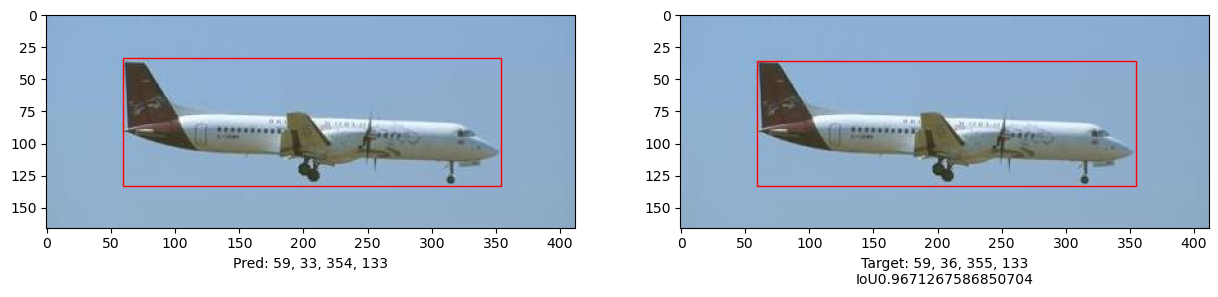

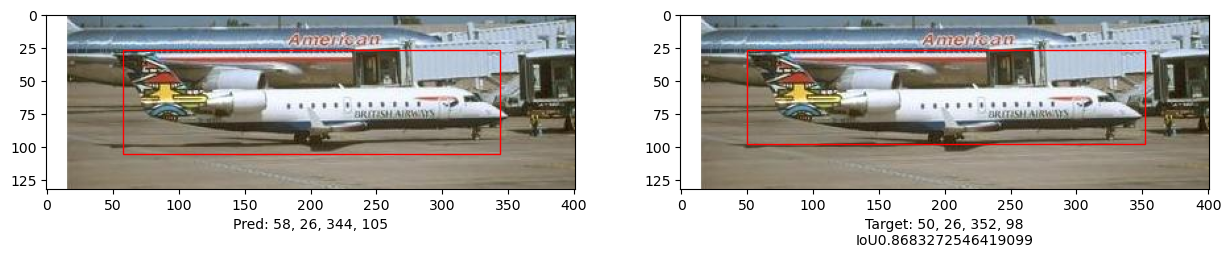

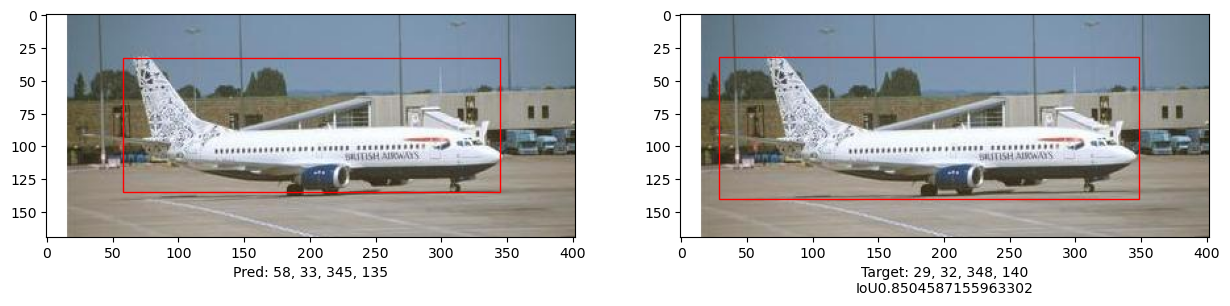

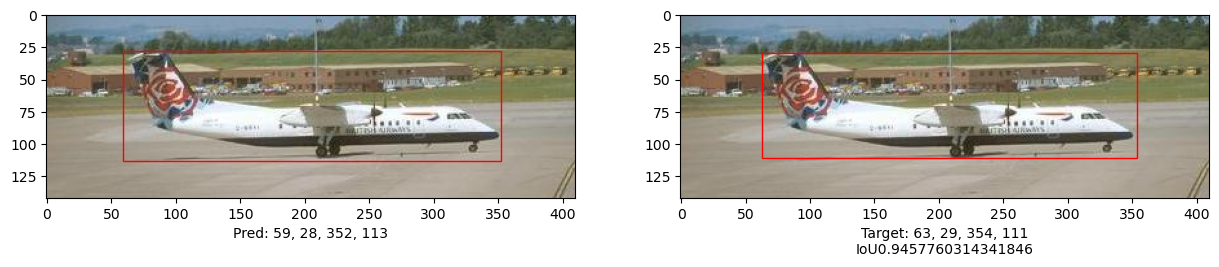

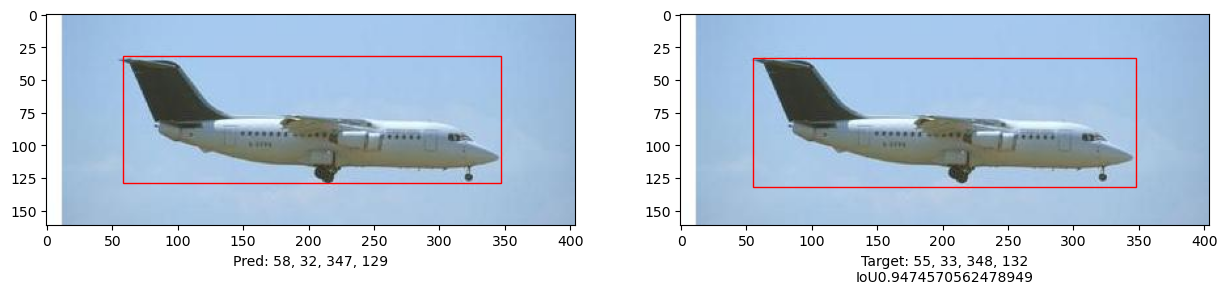

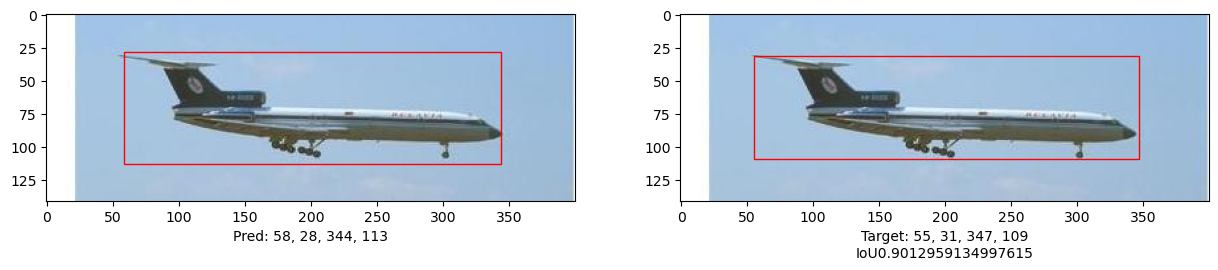

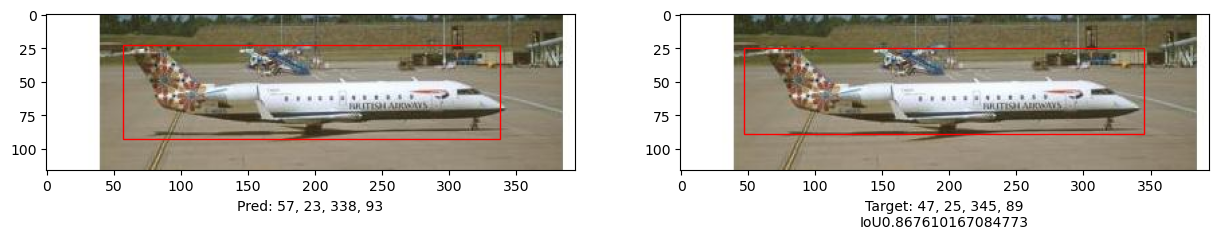

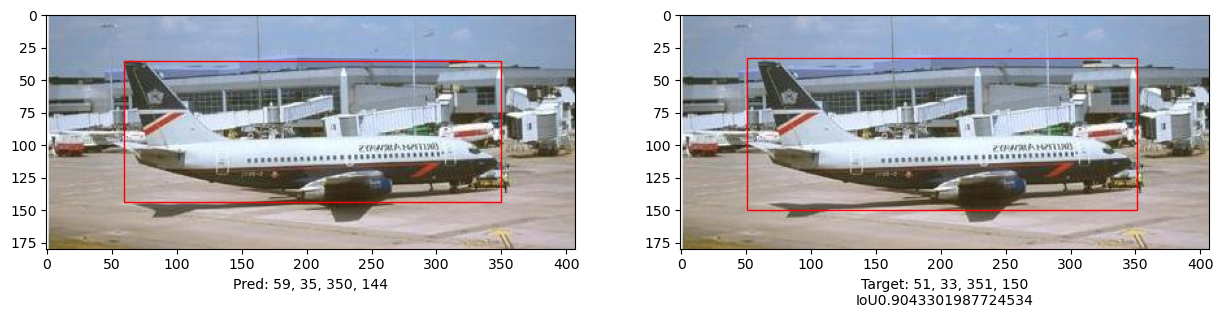

In [10]:
import matplotlib.patches as patches

vit_object_detector.save("vit_object_detector.h5", save_format = "h5")

def bounding_box_intersection_over_union(box_predicted, box_truth):
    top_x_intersect = max(box_predicted[0], box_truth[0])
    top_y_intersect = max(box_predicted[1], box_truth[1])
    bottom_x_intersect = min(box_predicted[2], box_truth[2])
    bottom_y_intersect = min(box_predicted[3], box_truth[3])

    # aria intersectiei dintre bounding box-uri
    intersection_area = max(0, bottom_x_intersect - top_x_intersect + 1) * max(
        0, bottom_y_intersect - top_y_intersect + 1
    )

    # aria predictiei si aria bounding box-ului stiut
    box_predicted_area = (box_predicted[2] - box_predicted[0] + 1) * (
        box_predicted[3] - box_predicted[1] + 1
    )
    box_truth_area = (box_truth[2] - box_truth[0] + 1) * (
        box_truth[3] - box_truth[1] + 1
    )

    # ioU
    return intersection_area / float(
        box_predicted_area + box_truth_area - intersection_area
    )


i, mean_iou = 0, 0

# Luam 15 de imagini din dataset
for input_image in x_test[:15]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 15))
    im = input_image

    # Afisare imagini
    ax1.imshow(im.astype("uint8"))
    ax2.imshow(im.astype("uint8"))

    input_image = cv2.resize(
        input_image, (image_size, image_size), interpolation=cv2.INTER_AREA
    )
    input_image = np.expand_dims(input_image, axis = 0)
    preds = vit_object_detector.predict(input_image)[0]

    (h, w) = (im).shape[0:2]

    top_left_x, top_left_y = int(preds[0] * w), int(preds[1] * h)

    bottom_right_x, bottom_right_y = int(preds[2] * w), int(preds[3] * h)

    box_predicted = [top_left_x, top_left_y, bottom_right_x, bottom_right_y]
    # Desenam bounding box-ul pe prediction
    rect = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor = "none",
        edgecolor = "red",
        linewidth = 1,
    )
    # Il adaugam
    ax1.add_patch(rect)
    ax1.set_xlabel("Pred: " + str(top_left_x) + ", " + str(top_left_y) + ", " +
                   str(bottom_right_x) + ", " + str(bottom_right_y))

    top_left_x, top_left_y = int(y_test[i][0] * w), int(y_test[i][1] * h)

    bottom_right_x, bottom_right_y = int(y_test[i][2] * w), int(y_test[i][3] * h)

    box_truth = top_left_x, top_left_y, bottom_right_x, bottom_right_y

    mean_iou += bounding_box_intersection_over_union(box_predicted, box_truth)
    # Bounding box stiut
    rect = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor  ="none",
        edgecolor = "red",
        linewidth = 1,
    )
    # Il adaugam
    ax2.add_patch(rect)
    ax2.set_xlabel("Target: " + str(top_left_x) + ", " + str(top_left_y) + ", " 
                   + str(bottom_right_x) + ", " + str(bottom_right_y) + "\nIoU" 
                   + str(bounding_box_intersection_over_union(box_predicted, box_truth)))
    i = i + 1

print("Mean IoU: " + str(mean_iou / len(x_test[:10])))
plt.show()